In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

# 1. Define Paths
base_path = r"C:\Users\thiranbarath\Documents\GitHub\project-d"
input_file = os.path.join(base_path, "machineLearning", "csv", "ml_ready_dataset.csv")

# 2. Load the data
print(f"Loading dataset from: {input_file}")
df = pd.read_csv(input_file)

print(f"✅ ML dataset loaded successfully. Total shape: {df.shape}")

Loading dataset from: C:\Users\thiranbarath\Documents\GitHub\project-d\machineLearning\csv\ml_ready_dataset.csv
✅ ML dataset loaded successfully. Total shape: (62135, 26)


In [2]:
# 1. Define the target variable for Model Track A
target = 'Admitted_Yes_No'

# 2. Define columns that cause Data Leakage for this specific model
# You cannot use hospital stay length or readmission status to predict initial admission
leakage_cols = ['Readmitted_Yes_No', 'Num_Admissions', 'Avg_LOS']

# 3. Separate Features (X) and Target (y)
X = df.drop(columns=[target] + leakage_cols, errors='ignore')
y = df[target]

print(f"Features (X) shape: {X.shape}")
print(f"Target (y) shape: {y.shape}")

# Display the raw class imbalance
print("\nReal-World Class Distribution (Admitted vs Not Admitted):")
print(y.value_counts(normalize=True) * 100)

Features (X) shape: (62135, 22)
Target (y) shape: (62135,)

Real-World Class Distribution (Admitted vs Not Admitted):
Admitted_Yes_No
0    87.126418
1    12.873582
Name: proportion, dtype: float64


In [3]:
# Split the data (80% Training, 20% Testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"✅ Training set: {X_train.shape[0]} patients")
print(f"✅ Testing set: {X_test.shape[0]} patients")

✅ Training set: 49708 patients
✅ Testing set: 12427 patients


--- PHASE 1: CORRELATION CHECK ---


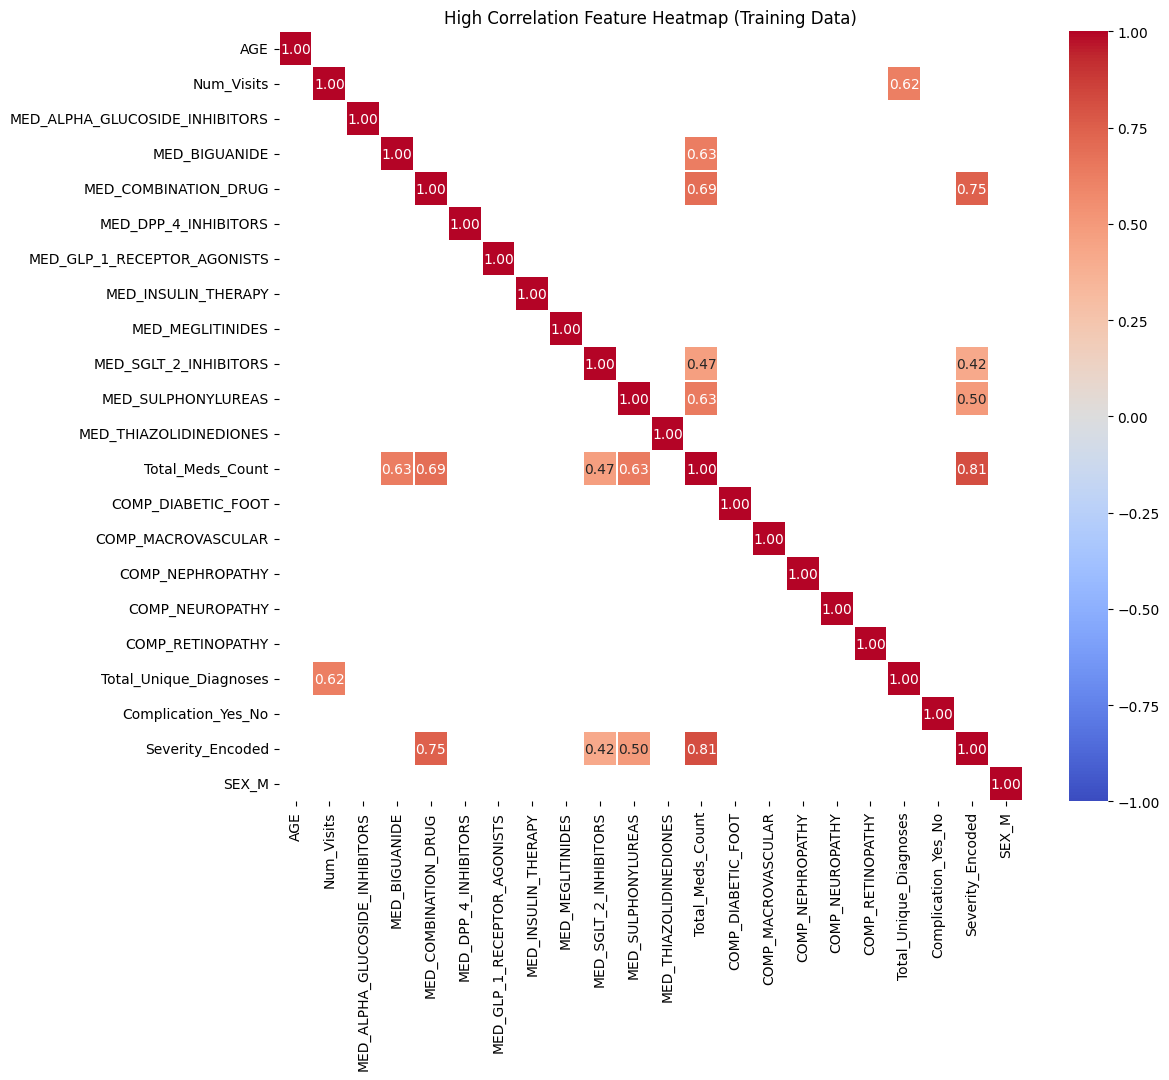


--- PHASE 2: TREE-BASED FEATURE IMPORTANCE ---

Feature Importance Rankings for Predicting Admission:
                       Feature  Importance
        Total_Unique_Diagnoses    0.357816
                           AGE    0.251485
                    Num_Visits    0.192036
              Total_Meds_Count    0.041689
              COMP_RETINOPATHY    0.031200
            COMP_MACROVASCULAR    0.026994
              Severity_Encoded    0.016415
                         SEX_M    0.016178
                 MED_BIGUANIDE    0.015353
          MED_COMBINATION_DRUG    0.010265
              COMP_NEPHROPATHY    0.007967
           Complication_Yes_No    0.007702
            MED_SULPHONYLUREAS    0.006039
         MED_SGLT_2_INHIBITORS    0.005978
               COMP_NEUROPATHY    0.004205
   MED_GLP_1_RECEPTOR_AGONISTS    0.002997
          MED_DPP_4_INHIBITORS    0.002561
           MED_INSULIN_THERAPY    0.001702
            COMP_DIABETIC_FOOT    0.000885
MED_ALPHA_GLUCOSIDE_INHIBITORS    0.0

In [4]:
print("--- PHASE 1: CORRELATION CHECK ---")
# 1. Correlation Matrix to find redundant features (Multicollinearity)
plt.figure(figsize=(12, 10))

# Calculate correlation on the training data only
corr_matrix = X_train.corr()

# Plot heatmap (Filtering to only show correlations > 0.4 or < -0.4 to keep it readable)
high_corr = corr_matrix[(corr_matrix >= 0.4) | (corr_matrix <= -0.4)]
sns.heatmap(high_corr, cmap='coolwarm', vmax=1.0, vmin=-1.0, linewidths=0.1, annot=True, fmt=".2f")
plt.title("High Correlation Feature Heatmap (Training Data)")
plt.show()

print("\n--- PHASE 2: TREE-BASED FEATURE IMPORTANCE ---")
# 2. Use a baseline Random Forest to rank features by predictive power
# We use class_weight='balanced' so the minority admission cases get equal voting power
rf_selector = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
rf_selector.fit(X_train, y_train)

# 3. Extract and display the rankings
feature_importances = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf_selector.feature_importances_
}).sort_values(by='Importance', ascending=False)

print("\nFeature Importance Rankings for Predicting Admission:")
print(feature_importances.to_string(index=False))

In [5]:
print("--- PHASE 2.5: FEATURE SELECTION & SCALING ---")

# 1. Drop features that scored below 0.005 in the Gini Importance check
features_to_drop = [
    'COMP_NEUROPATHY',
    'MED_GLP_1_RECEPTOR_AGONISTS',
    'MED_DPP_4_INHIBITORS',
    'MED_INSULIN_THERAPY',
    'COMP_DIABETIC_FOOT',
    'MED_ALPHA_GLUCOSIDE_INHIBITORS',
    'MED_THIAZOLIDINEDIONES',
    'MED_MEGLITINIDES'
]

# Apply the drops safely
X_train_final = X_train.drop(columns=features_to_drop, errors='ignore')
X_test_final = X_test.drop(columns=features_to_drop, errors='ignore')

print(f"✅ Dropped {len(features_to_drop)} low-importance features to reduce mathematical noise.")

# 2. Initialize the Standard Scaler
scaler = StandardScaler()

# 3. Scale the data
# We fit ONLY on the training data so the model can't peek at the test set's distribution
X_train_scaled = scaler.fit_transform(X_train_final)
X_test_scaled = scaler.transform(X_test_final)

# Convert the scaled numpy arrays back into Pandas DataFrames for readability
X_train_final = pd.DataFrame(X_train_scaled, columns=X_train_final.columns)
X_test_final = pd.DataFrame(X_test_scaled, columns=X_test_final.columns)

print(f"✅ Final Training features shape: {X_train_final.shape}")
print(f"✅ Final Testing features shape: {X_test_final.shape}")
print("Ready for Model Training!")

--- PHASE 2.5: FEATURE SELECTION & SCALING ---
✅ Dropped 8 low-importance features to reduce mathematical noise.
✅ Final Training features shape: (49708, 14)
✅ Final Testing features shape: (12427, 14)
Ready for Model Training!


In [6]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

print("--- PHASE 3: MODEL TRAINING ---")

# Calculate the exact imbalance ratio for XGBoost later
negative_cases = (y_train == 0).sum()
positive_cases = (y_train == 1).sum()
scale_weight = negative_cases / positive_cases

print(f"Dataset Imbalance Ratio: 1 Admission for every {scale_weight:.2f} Non-Admissions.\n")

# --- 1. Logistic Regression ---
print("Training Logistic Regression...")
start_time = time.time()
lr_model = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
lr_model.fit(X_train_final, y_train)
print(f"✅ LR Trained in {time.time() - start_time:.2f} seconds")

--- PHASE 3: MODEL TRAINING ---
Dataset Imbalance Ratio: 1 Admission for every 6.77 Non-Admissions.

Training Logistic Regression...
✅ LR Trained in 0.06 seconds


In [7]:
# --- 2. Random Forest ---
print("Training Random Forest...")
start_time = time.time()
rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced', n_jobs=-1)
rf_model.fit(X_train_final, y_train)
print(f"✅ RF Trained in {time.time() - start_time:.2f} seconds")

Training Random Forest...
✅ RF Trained in 0.81 seconds


In [8]:
# --- 3. XGBoost ---
print("Training XGBoost...")
start_time = time.time()
xgb_model = XGBClassifier(
    random_state=42, 
    scale_pos_weight=scale_weight, 
    eval_metric='logloss',
    n_jobs=-1
)
xgb_model.fit(X_train_final, y_train)
print(f"✅ XGBoost Trained in {time.time() - start_time:.2f} seconds")

Training XGBoost...
✅ XGBoost Trained in 0.16 seconds


In [9]:
from sklearn.metrics import classification_report

print("--- PHASE 4: EVALUATION ON TEST SET ---\n")

# 1. Generate Predictions
y_pred_lr = lr_model.predict(X_test_final)
y_pred_rf = rf_model.predict(X_test_final)
y_pred_xgb = xgb_model.predict(X_test_final)

# 2. Print Reports
print("--- LOGISTIC REGRESSION ---")
# We focus on the row for '1' (Admitted)
print(classification_report(y_test, y_pred_lr))

print("\n--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

print("\n--- XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

--- PHASE 4: EVALUATION ON TEST SET ---

--- LOGISTIC REGRESSION ---
              precision    recall  f1-score   support

           0       0.95      0.84      0.89     10827
           1       0.39      0.68      0.50      1600

    accuracy                           0.82     12427
   macro avg       0.67      0.76      0.69     12427
weighted avg       0.88      0.82      0.84     12427


--- RANDOM FOREST ---
              precision    recall  f1-score   support

           0       0.92      0.83      0.87     10827
           1       0.31      0.52      0.39      1600

    accuracy                           0.79     12427
   macro avg       0.62      0.67      0.63     12427
weighted avg       0.84      0.79      0.81     12427


--- XGBOOST ---
              precision    recall  f1-score   support

           0       0.96      0.76      0.85     10827
           1       0.33      0.79      0.46      1600

    accuracy                           0.76     12427
   macro avg       

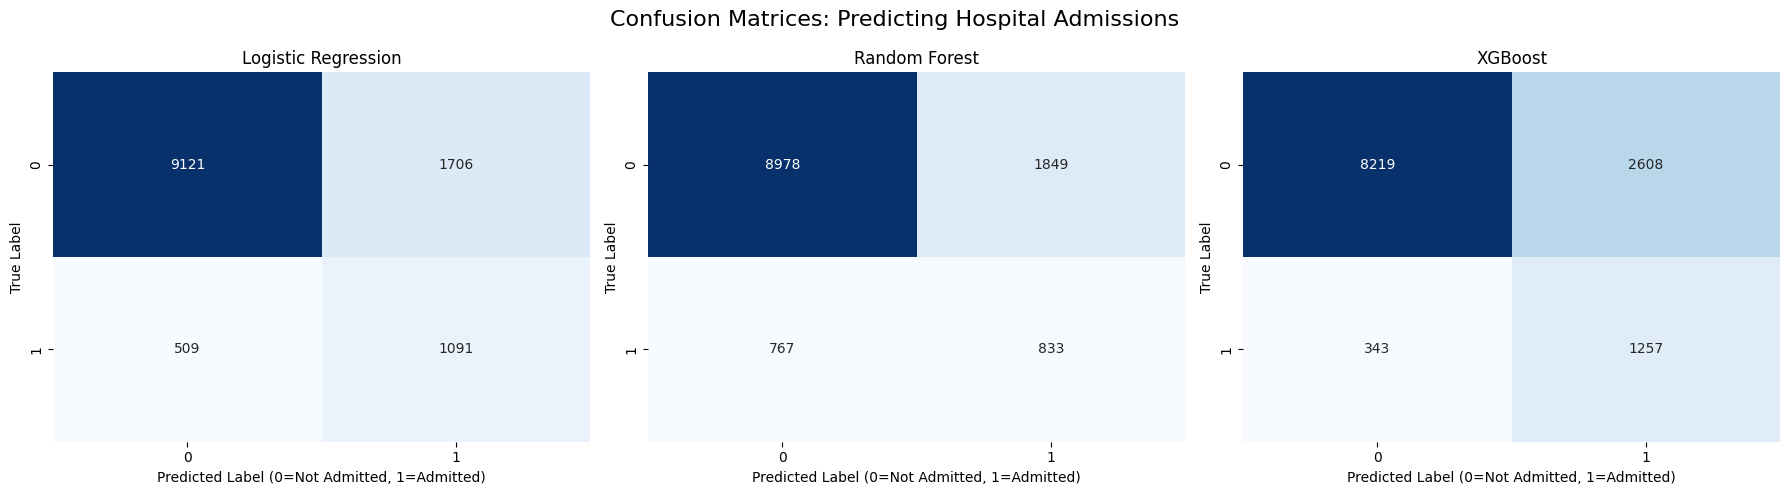

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Predicting Hospital Admissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=Not Admitted, 1=Admitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
plt.show()

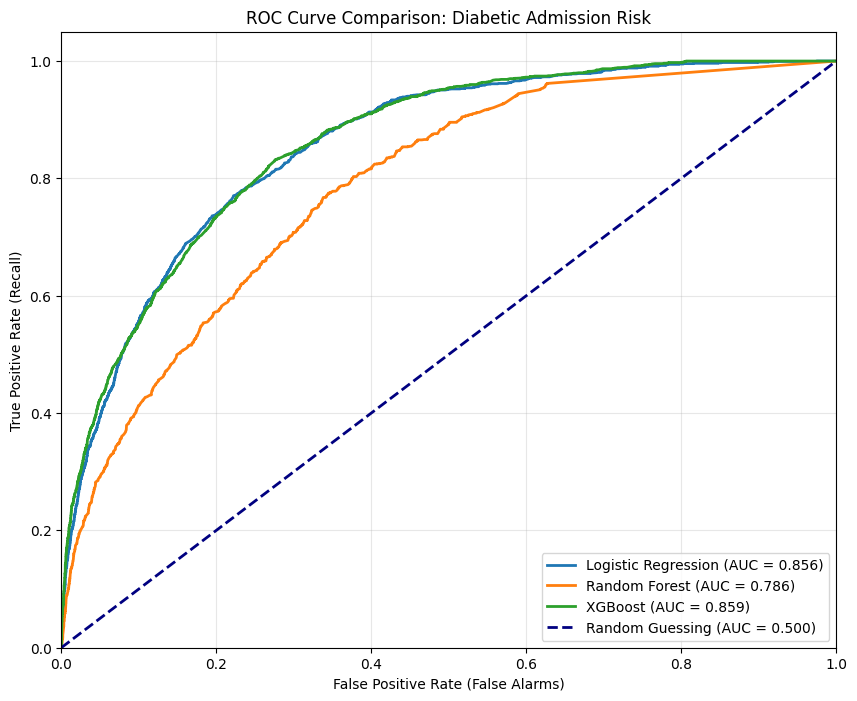

In [11]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

# We need the *probabilities* (confidence levels) to draw this curve, not just the final 1/0 answer
models_proba = [
    ('Logistic Regression', lr_model.predict_proba(X_test_final)[:, 1]),
    ('Random Forest', rf_model.predict_proba(X_test_final)[:, 1]),
    ('XGBoost', xgb_model.predict_proba(X_test_final)[:, 1])
]

# Plot each model's curve
for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

# Draw the 50/50 guessing line
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Diabetic Admission Risk')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

In [12]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

print("--- PHASE 4.5: SAVING METRICS TO DISK ---\n")

# 1. Define and create the plots directory
plots_dir = os.path.join(base_path, "machineLearning", "plots")
os.makedirs(plots_dir, exist_ok=True)
print(f"Directory ready: {plots_dir}")

# ==========================================
# 2. SAVE CLASSIFICATION REPORTS (TEXT FILE)
# ==========================================
report_path = os.path.join(plots_dir, "01_Admission_Classification_Reports.txt")
with open(report_path, "w") as f:
    f.write("--- LOGISTIC REGRESSION ---\n")
    f.write(classification_report(y_test, y_pred_lr))
    f.write("\n\n--- RANDOM FOREST ---\n")
    f.write(classification_report(y_test, y_pred_rf))
    f.write("\n\n--- XGBOOST ---\n")
    f.write(classification_report(y_test, y_pred_xgb))
print(f"✅ Saved text reports to: 01_Admission_Classification_Reports.txt")

# ==========================================
# 3. SAVE CONFUSION MATRICES (IMAGE)
# ==========================================
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Confusion Matrices: Predicting PMCare Hospital Admissions', fontsize=16)

models = [
    ('Logistic Regression', y_pred_lr),
    ('Random Forest', y_pred_rf),
    ('XGBoost', y_pred_xgb)
]

for i, (name, y_pred) in enumerate(models):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i], cbar=False)
    axes[i].set_title(f'{name}')
    axes[i].set_xlabel('Predicted Label (0=Not Admitted, 1=Admitted)')
    axes[i].set_ylabel('True Label')

plt.tight_layout()
cm_path = os.path.join(plots_dir, "02_Admission_Confusion_Matrices.png")
plt.savefig(cm_path, dpi=300, bbox_inches='tight') # dpi=300 ensures print-quality resolution
plt.close() # Closes the plot so it doesn't double-print in the notebook
print(f"✅ Saved confusion matrices to: 02_Admission_Confusion_Matrices.png")

# ==========================================
# 4. SAVE ROC-AUC CURVE (IMAGE)
# ==========================================
plt.figure(figsize=(10, 8))

models_proba = [
    ('Logistic Regression', lr_model.predict_proba(X_test_final)[:, 1]),
    ('Random Forest', rf_model.predict_proba(X_test_final)[:, 1]),
    ('XGBoost', xgb_model.predict_proba(X_test_final)[:, 1])
]

for name, y_proba in models_proba:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guessing (AUC = 0.500)')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (False Alarms)')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve Comparison: Diabetic Admission Risk')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

roc_path = os.path.join(plots_dir, "03_Admission_ROC_Curve.png")
plt.savefig(roc_path, dpi=300, bbox_inches='tight')
plt.close()
print(f"✅ Saved ROC curve to: 03_Admission_ROC_Curve.png")

print("\n🎉 All evaluation assets successfully saved to disk!")

--- PHASE 4.5: SAVING METRICS TO DISK ---

Directory ready: C:\Users\thiranbarath\Documents\GitHub\project-d\machineLearning\plots
✅ Saved text reports to: 01_Admission_Classification_Reports.txt
✅ Saved confusion matrices to: 02_Admission_Confusion_Matrices.png
✅ Saved ROC curve to: 03_Admission_ROC_Curve.png

🎉 All evaluation assets successfully saved to disk!


--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---



C:\Users\thiranbarath\AppData\Local\Temp\ipykernel_13760\3170280567.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='viridis')


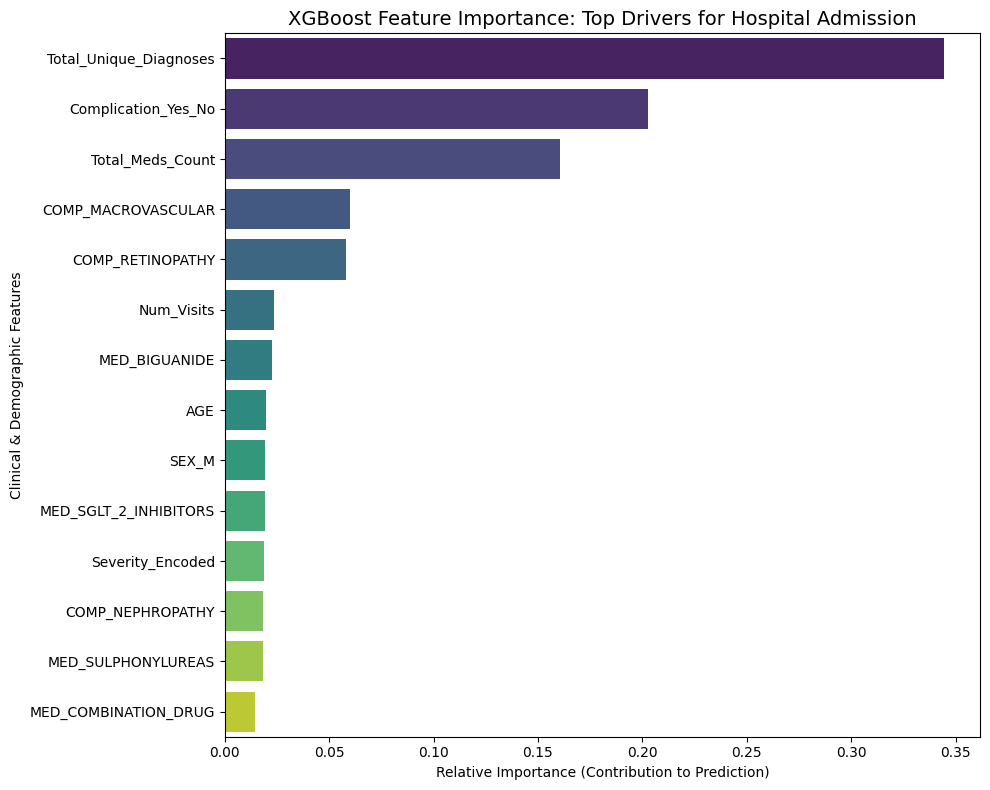

✅ Saved XGBoost Feature Importance plot to: C:\Users\thiranbarath\Documents\GitHub\project-d\machineLearning\plots\04_Admission_XGBoost_Importance.png

Top 5 Leading Indicators for PMCare Hospital Admissions:
               Feature  Importance
Total_Unique_Diagnoses    0.344502
   Complication_Yes_No    0.202569
      Total_Meds_Count    0.160425
    COMP_MACROVASCULAR    0.060134
      COMP_RETINOPATHY    0.058162


In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

print("--- PHASE 5: MODEL INTERPRETABILITY (XGBOOST) ---\n")

# 1. Extract the feature importance scores directly from the trained XGBoost model
xgb_importance = pd.DataFrame({
    'Feature': X_train_final.columns,
    'Importance': xgb_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

# 2. Plot the results
plt.figure(figsize=(10, 8))
sns.barplot(x='Importance', y='Feature', data=xgb_importance, palette='viridis')
plt.title('XGBoost Feature Importance: Top Drivers for Hospital Admission', fontsize=14)
plt.xlabel('Relative Importance (Contribution to Prediction)')
plt.ylabel('Clinical & Demographic Features')
plt.tight_layout()

# 3. Save the plot to your plots folder
plots_dir = os.path.join(base_path, "machineLearning", "plots")
importance_path = os.path.join(plots_dir, "04_Admission_XGBoost_Importance.png")
plt.savefig(importance_path, dpi=300)
plt.show()

print(f"✅ Saved XGBoost Feature Importance plot to: {importance_path}\n")

print("Top 5 Leading Indicators for PMCare Hospital Admissions:")
print(xgb_importance.head(5).to_string(index=False))